# [A4] Principal Component Analysis (PCA)

In this exercise, the concept of **dimensionality reduction** is introduced by implementing a principal componant analysis (PCA) step-by-step using eigendecomposition, calculating characteristic polynomials, eigenvalues and -vectors and of course principal components.

## 1: What is PCA?
The goal of PCA is to identify patterns in data by exploring the correlation between variables. If variables are strongly correlated, the dimensionality of a problem can be reduced using PCA: in simple terms, two or more features of a dataset can be combined into a fewer number of features that are calculated using the PCA. 

The idea is to identify the directions with maximum variance (eigenvectors) in high $d$-dimensional data and project the data to a smaller ($k$)-dimensional subspace ($k < d$) while retaining most of the information.

A summary of the PCA approach:
1. Determining eigenvectors and eigenvalues using covariance matrix. 
2. Sorting eigenvalues in descending order and selecting $k$ eigenvectors corresponding to the $k$ largest eigenvalues.
3. Constructing a projection matrix $W$ from the selected $k$ eigenvectors.
4. Transforming the original data set X over W to obtain a $k$-dimensional feature subspace $Y$.


## 2: Applying PCA to the IRIS dataset
To provide a practical understanding of PCA, the concept is implemented below using the IRIS dataset (which was introduced in the first exercise).

### 2.1: Preprocessing: Import & Visualization
As usual, we start by importing and then splitting the data into features ($X$) and labels ($y$).

In [11]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA


iris_data_raw = pd.read_csv(
    "../data/iris.data",
    header=None,
    sep=",",
    names=["sepal_length", "sepal_width", "petal_length", "petal_width", "class"],
)

# split data table into data X and class labels y
iris_X = iris_data_raw.iloc[:, 0:4].values
iris_y = iris_data_raw.iloc[:, 4].values

display(iris_data_raw.head(2), iris_X.shape, iris_X[0:3])


,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa


(150, 4)

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

The distribution of the feature values for each of the 3 different flower classes can be visualized via histograms:

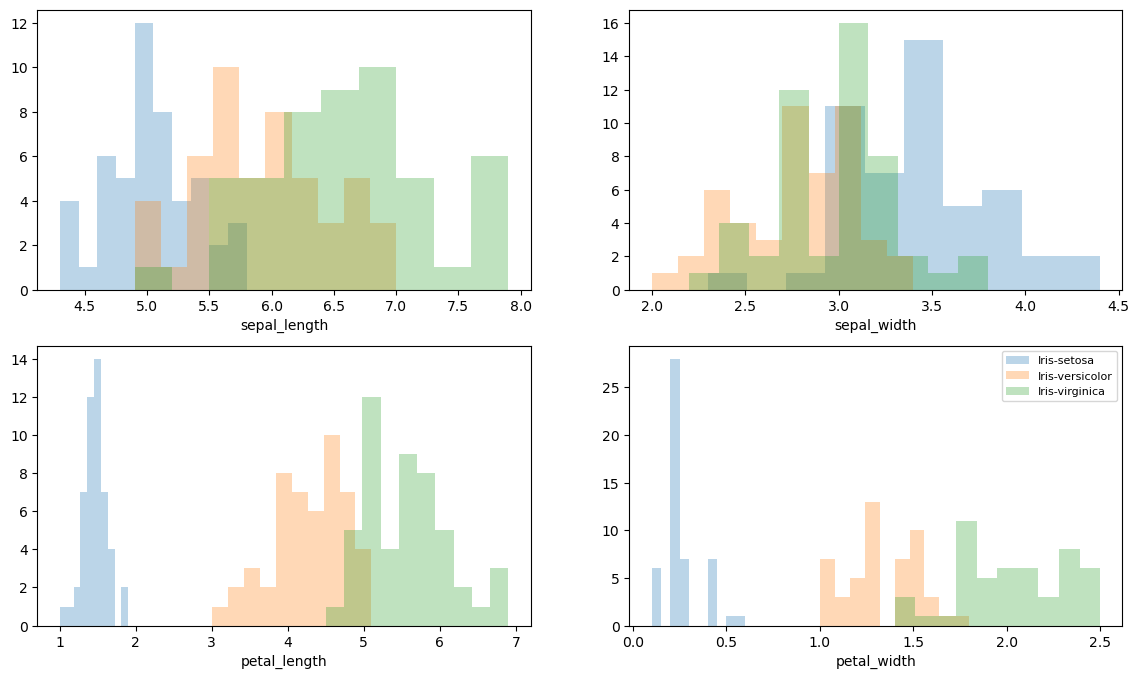

In [12]:
plt.figure(figsize=(14, 8))
for colid, colname in enumerate(iris_data_raw.columns[:-1]):
    plt.subplot(2, 2, colid + 1)
    for lab in iris_data_raw["class"].unique():
        plt.hist(
            iris_X[iris_y == lab, colid],
            label=lab,
            bins=10,
            alpha=0.3,
        )
    plt.xlabel(colname)
plt.legend(loc="upper right", fancybox=True, fontsize=8)

plt.show()


### 2.2: ✏️ Calculation of the covariance matrix $C$
The "core" principle of PCA is to retreive eigenvectors and eigenvalues of the covariance matrix $C \in \R^{d \times d}$ of the dataset $ g $ using an eigendecomposition.

Each element $ \sigma_{jk} \in C $ represents the covariance between two features. 


<!-- $\sigma_{jk} = \frac{1}{n-1}\sum_{i=1}^{n}\left( x_{ij}-\bar{x}_j \right) \left( x_{ik}-\bar{x}_k \right).$ -->

The calculation of the covariance matrix is summarized by the following matrix equation:

$C = \frac{1}{N-1} G G^T $ 
with the centered dataset $ G = (g^T - g_{mean})^T \in  \mathbb{R}^{d \times N}$ 
and the mean vector $g_{mean} = \left( \frac{1}{N} \sum\limits_{n=1}^N g_{n} \right) \in \mathbb{R}^d$ containing the mean for each feature of the dataset.

✏️ Implement the covariance matrix on your own (using numpy methods). Verify the result of your implementation using the ``numpy.cov()`` function.
Note that numpy requires you to transpose your DataFrame values first, as it expects each object to be represented as a column.

In [13]:

#sepal_length	sepal_width	petal_length	petal_width
def covariance_matrix(g):
    g_mean = np.mean(g, axis=1, keepdims=True)
    print("g_mean", g_mean)
    delta_g = g - g_mean
    #delta_g = delta_g.T
    #print("delta_g", delta_g)
    n = np.shape(g)[1]
    cov_m = (1 / (n - 1)) * np.matmul(delta_g, delta_g.T)
    
    return cov_m


cov_mat = covariance_matrix(iris_X.T)
print("Covariance matrix: ", cov_mat)
print(cov_mat.shape)
print("NumPy covariance matrix: ", np.cov(iris_X.T))


g_mean [[5.84333333]
 [3.054     ]
 [3.75866667]
 [1.19866667]]
Covariance matrix:  [[ 0.68569351 -0.03926846  1.27368233  0.5169038 ]
 [-0.03926846  0.18800403 -0.32171275 -0.11798121]
 [ 1.27368233 -0.32171275  3.11317942  1.29638747]
 [ 0.5169038  -0.11798121  1.29638747  0.58241432]]
(4, 4)
NumPy covariance matrix:  [[ 0.68569351 -0.03926846  1.27368233  0.5169038 ]
 [-0.03926846  0.18800403 -0.32171275 -0.11798121]
 [ 1.27368233 -0.32171275  3.11317942  1.29638747]
 [ 0.5169038  -0.11798121  1.29638747  0.58241432]]


### 2.3: Eigendecomposition - Calculation of eigenvectors and eigenvalues
Given the covariance matrix, we can now perform an eigendecomposition of it, providing both

- the eigenvectors (principal components) that determine the directions of the new feature space and
- the eigenvalues that determine the magnitude/size (they explain the variance of the data along the new feature axes).

#### 2.3.1: ✏️ Characteristic Polynomial and Eigenvalues

The **eigenvalues** are defined as the zero points of the **characteristic polynomial**. 

1. Calculate the characteristic polynomial:

In [14]:
"""
det(A - λ I)
"""
test_M = np.array([[10/4, 6/4], [6/4, 10/4]])
# Its roots are the eigenvalues of A.
# For a 2×2 matrix A = [[a, b], [c, d]], the polynomial is
# λ^2 - (a + d) λ + (a d - b c).
# char_poly = det(cov - np.identity(cov.shape[0]) * lamda

cov = cov_mat
coeffs = np.poly(cov)
print("Characteristic polynomial coefficients (highest-degree first):")
print(coeffs)


Characteristic polynomial coefficients (highest-degree first):
[ 1.00000000e+00 -4.56929128e+00  1.48186720e+00 -1.12910083e-01
  1.90327580e-03]


2. Calculate the eigenvalues $ \lambda_i $:

In [15]:
# TODO: Implement

eigenvalues = np.roots(coeffs)
print("Eigenvalues :", eigenvalues)


Eigenvalues : [4.22484077 0.24224357 0.07852391 0.02368303]


#### 2.3.2: Eigenvectors Explanation
**Eigenvectors** $ \vec{e}_i $ are retrieved by solving the following linear equation (with the identity matrix $I$): 

$$ C-\lambda_i \cdot I \cdot \vec{e}_i = \vec{0} $$


In the lecture and in the exam (if this task is given), the linear equation system (_LGS_) is solved by hand at this point. 

Unfortunately, however, the common linear algebra solvers, such as numpys ``linalg.solve()``, generate only the trivial solution (you are welcome to try it out).

We herefore deviate from the lecture script and perform a [QR decomposition](https://en.wikipedia.org/wiki/QR_decomposition):

For each eigenvalue $ \lambda_i $:

1. Calculate the matrix $ m_i = (C - \lambda_i \cdot I) $ and perform a QR decomposition of $m_i^T$ using numpy, returning the matrices $q_i$ and $r_i$.

2. Determine the rank $rank(m_i)$ of the matrix as follows: 
      1. Get the index of the row in $r_i$ where all values are $0$ or "close to it" 
      2. Rank = that index (when starting index at 0)
      3. Example:  $ rank(m_i) = 3 $

         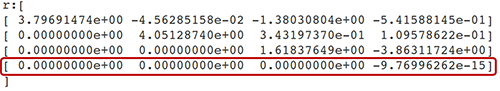

3. Determine the eigenvector(s) $ \vec{e}_i $ as follows:
      1. The eigenvectors are contained in the last $ |q_i| - rank(m_i) $ columns of $ q_i $.
      2. Example: given $ rank(m_i) = 3 $, the first $ 4 - 3 = 1 $ columns from the end are the eigenvectors (=the fourth column considered from the beginning)

         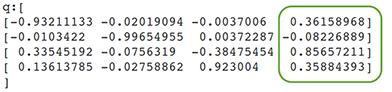


#### 2.3.3: ✏️ Eigenvectors Implementation

1. Implement the above method to calculate the eigenvectors and verify the result of your implementation using numpys ``linalg.eig()`` function.

In [16]:
from numpy import linalg as LA

eig_vecs = pd.DataFrame()
C = cov_mat

print("Check with:")
eval, evec = LA.eig(C)
print("eigenvalues", eval)
print("eigenvectors", evec)
print("--------")


def first_zero_row_index(R, atol=1e-10):
    for i, row in enumerate(R):
        if np.allclose(row, 0, atol=atol):
            return i
    return None
    

# TODO: Implement
# 1. m_i = (C - \lambda_i \cdot I)

ms = []
for lam in eigenvalues:
    m = C - lam * np.eye(C.shape[0])
    ms.append(m)

for m_i in ms:
    Q, R = np.linalg.qr(m_i.T)
    # find row with most zeros
    #print("R",R)
    rank = first_zero_row_index(R)
    if rank is None:
        print("No index found")
    #print("Q",Q)
    #print("Rank Index:", rank)
    
    # extract eigenvectors
    num_eigenvectors = Q.shape[1] - rank
    eigenvector = Q[:, -num_eigenvectors:]
    eigenvector_df = pd.DataFrame(eigenvector)

    #print("Eigenvec:", eigenvector)
    #print("Eigenvector shape:", eigenvector.shape)
    eig_vecs = pd.concat([eig_vecs, eigenvector_df], axis=1, ignore_index=True)
    
display("Eigenvektoren:", eig_vecs)

Check with:
eigenvalues [4.22484077 0.24224357 0.07852391 0.02368303]
eigenvectors [[ 0.36158968 -0.65653988 -0.58099728  0.31725455]
 [-0.08226889 -0.72971237  0.59641809 -0.32409435]
 [ 0.85657211  0.1757674   0.07252408 -0.47971899]
 [ 0.35884393  0.07470647  0.54906091  0.75112056]]
--------


'Eigenvektoren:'

,0,1,2,3
0,0.361590,-0.656540,-0.580997,0.317255
1,-0.082269,-0.729712,0.596418,-0.324094
2,0.856572,0.175767,0.072524,-0.479719
3,0.358844,0.074706,0.549061,0.751121


### 2.4: Selecting Principal Components
As mentioned, the goal of the PCA is to reduce the dimensionality of the original feature space by projecting it onto a smaller subspace.

In this subspace, the eigenvectors form the _axes_ of the coordinate system, or more precisely, their directions - as all eigenvectors have the same unit length of 1: 

In [17]:
#print(eig_vecs.T)
for fname, series in eig_vecs.items():
    ev = series.to_numpy()
    print(ev)
    print(np.linalg.norm(ev))
    np.testing.assert_array_almost_equal(1.0, np.linalg.norm(ev))
print("Ok Ok!")


[ 0.36158968 -0.08226889  0.85657211  0.35884393]
1.0
[-0.65653988 -0.72971237  0.1757674   0.07470647]
0.9999999999999999
[-0.58099728  0.59641809  0.07252408  0.54906091]
1.0
[ 0.31725455 -0.32409435 -0.47971899  0.75112056]
1.0
Ok Ok!


To reduce the number of dimensions (and _axes_) we need to reduce the number of eigenvectors.

To decide which eigenvector(s) can be dropped without losing too much information, the corresponding eigenvalues must be examined: 

The eigenvectors with the lowest eigenvalues contain the least information about the distribution of the data and can be dropped.


#### 2.4.1: ✏️ Sorting the eigenpairs
1. Generate a list of tuples containing the eigenvalues and eigenvectors. Sort them based on eigenvalues from highest to lowest:

In [18]:
# TODO: Implement
# compose tupels
eigen_df = np.append(eig_vecs, [eigenvalues], axis=0)
eigen_tupels = list(map(tuple,eigen_df.T))
sorted_eig_tupels = sorted(eigen_tupels, key=lambda x: x[4], reverse=True)

display(sorted_eig_tupels)

[(np.float64(0.36158967738145),
  np.float64(-0.08226888989221415),
  np.float64(0.8565721052905285),
  np.float64(0.35884392624821393),
  np.float64(4.224840768320112)),
 (np.float64(-0.656539883285831),
  np.float64(-0.7297123713264969),
  np.float64(0.17576740342865443),
  np.float64(0.07470647013503293),
  np.float64(0.24224357162751547)),
 (np.float64(-0.5809972798276182),
  np.float64(0.5964180879381027),
  np.float64(0.07252407548696393),
  np.float64(0.5490609107266033),
  np.float64(0.07852390809415448)),
 (np.float64(0.3172545471685433),
  np.float64(-0.3240943524179694),
  np.float64(-0.47971898732994017),
  np.float64(0.7511205603808195),
  np.float64(0.023683027126001618))]

#### 2.4.2: ✏️ Determining the best number of Principal Components (Explained Variance)
After sorting the eigenpairs, you may ask yourself how many principal components you should keep for the new feature subspace.
A useful measure is the so-called **explained variance**, which can be calculated from the eigenvalues, indicating how much information (variance) can be assigned to each principal component.

1. Determine the explained variance by calculating the percentage of each eigenvalue in the total sum of eigenvalues:

In [19]:
# TODO: Implement
variance_sum = eigenvalues.sum()
for eig in eigenvalues:
    print("explained var:", eig/variance_sum * 100)

explained var: 92.46162071742683
explained var: 5.3015567850535055
explained var: 1.7185139525006772
explained var: 0.5183085450189862


These results show that most (92.46%) of the variance can be explained by the first principal component alone. 

The second principal component still contains some information (5.30%), while the third and fourth principal components can be safely dropped without losing too much information. 

--> Together, the first two principal components contain 97.76% of the information ==> $k=2$

### 2.5: ✏️ Creating the Projection Matrix $W$
We can now construct the projection matrix used to transform the Iris data into the new ($k=2$, two-dimensional) feature subspace.

The projection matrix $W \in \R^{d\times k}$ contains the top-$k$ eigenvectors as columns (and is sometimes called _eigenvector matrix_).

1. Generate the projection matrix $W$ for $k=2$ from the sorted eigenpairs.

In [20]:
import math
k = 2
# TODO: Implement
display(eigen_df)
imp_eigenvec_def = eigen_df[:-1, :k]
W = (1 / math.sqrt(k)) * imp_eigenvec_def
W
# keep first two tupels & drop eigenwerte
# np.delete(eigen_df, eigen_df.itemsize, 0)
# multiplicate by sqrt(k), to scale 

array([[ 0.36158968, -0.65653988, -0.58099728,  0.31725455],
       [-0.08226889, -0.72971237,  0.59641809, -0.32409435],
       [ 0.85657211,  0.1757674 ,  0.07252408, -0.47971899],
       [ 0.35884393,  0.07470647,  0.54906091,  0.75112056],
       [ 4.22484077,  0.24224357,  0.07852391,  0.02368303]])

array([[ 0.25568251, -0.4642438 ],
       [-0.05817289, -0.51598457],
       [ 0.60568794,  0.12428632],
       [ 0.25374097,  0.05282545]])

### 2.6: ✏️ Projecting the data into the new feature subspace

In this final step, the $4 \times 2$-dimensional projection matrix W is used to transform the data $X$ to the new subspace.

Mathematically, this is a simple dot product: $\hat{X}=X \cdot W$ 

1. Use the projection matrix $W$ to transform the iris dataset (``iris_X``) to fewer dimensions and output the shape of the transformed dataset.

In [21]:
# TODO: Implement
iris_X_transformed = iris_X @ W
display(iris_X_transformed)

array([[ 1.99908702, -3.98902344],
       [ 1.97703696, -3.63818239],
       [ 1.85369709, -3.66095918],
       [ 1.95508371, -3.53807908],
       [ 1.96770148, -3.99419751],
       [ 2.28497719, -4.28683942],
       [ 1.90243715, -3.70002053],
       [ 2.03990485, -3.87857197],
       [ 1.85501299, -3.35446204],
       [ 2.00641437, -3.68263476],
       [ 2.12472599, -4.21906486],
       [ 2.04933714, -3.77329457],
       [ 1.92609461, -3.59704056],
       [ 1.61654697, -3.40220455],
       [ 2.02784074, -4.59684365],
       [ 2.21145791, -4.70896211],
       [ 2.04270202, -4.33655395],
       [ 2.02446111, -3.98374089],
       [ 2.34212514, -4.37979665],
       [ 2.06757804, -4.12610763],
       [ 2.26331544, -4.03941222],
       [ 2.09876943, -4.06922663],
       [ 1.62315329, -3.85821452],
       [ 2.26855027, -3.83269299],
       [ 2.23104352, -3.73600868],
       [ 2.1237428 , -3.65974951],
       [ 2.15122184, -3.85557825],
       [ 2.08522406, -4.02301919],
       [ 2.03047256,

### 2.7: Visualizing the projection
We have now reduced the four-dimensional feature space of the Iris dataset to two dimensions.

We can visualize these two dimensions using the following plot:

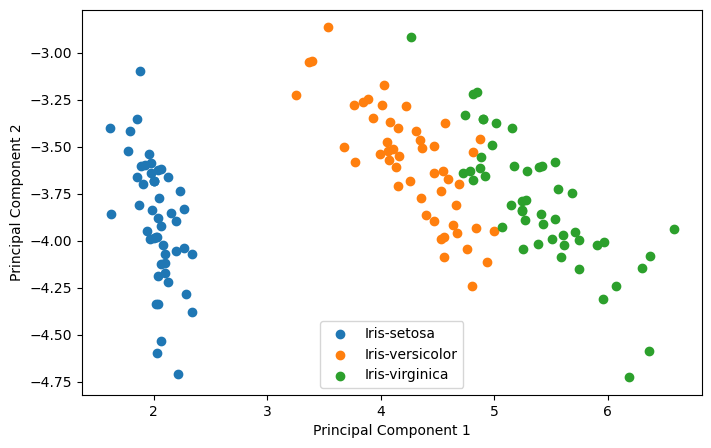

In [22]:
plt.figure(figsize=(8, 5))
for id, classname in enumerate(iris_data_raw["class"].unique()):
    plt.scatter(
        iris_X_transformed[iris_y == classname, 0],
        iris_X_transformed[iris_y == classname, 1],
        label=classname,
        c=f"C{id}",
    )
plt.gca().update(dict(xlabel="Principal Component 1", ylabel="Principal Component 2"))
plt.legend(loc="lower center")
plt.show()


Ideally, for the three classes of flowers you should see three distinct (or at least well separable) clusters. 

## 3: Applying PCA to the Fashion MNIST dataset
As a tribute to the popular MNIST image dataset of handwritten digits, fashion retail company Zalando created a dataset of similar shape and size showing images of clothing instead.

Each of the 70.000 grayscale images has 28x28 pixels.

We can apply the same techniques learned above to reduce the datasets complexity and visualize clusters in a lower dimension.

### 3.1: Import and Visualization
The data for this exercise is given in a CSV form. In practice, many image datasets will instead be provided using .png files.

,Category,Pixel000,Pixel001,Pixel002,Pixel003,Pixel004,Pixel005,Pixel006,Pixel007,Pixel008,...,Pixel774,Pixel775,Pixel776,Pixel777,Pixel778,Pixel779,Pixel780,Pixel781,Pixel782,Pixel783
Id,,,,,,,,,,,,,,,,,,,,,
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


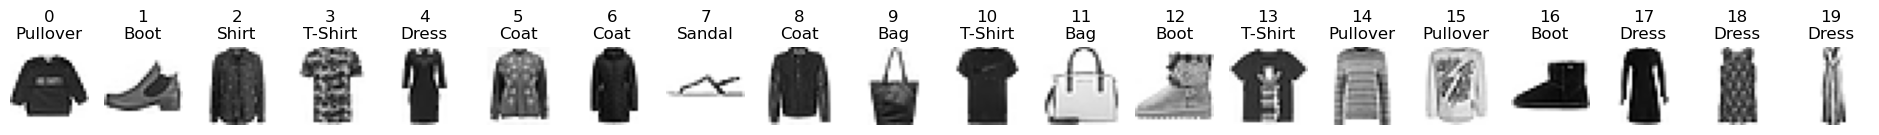

In [23]:
# Load Dataset
fm = pd.read_csv("../data/fashion_mnist_train.csv.zip", index_col="Id")
fm_labels = ["T-Shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Boot"]
display(fm.head(2))

# Visualize Examples
num_samples = 20
ax = plt.subplots(nrows=1, ncols=num_samples, figsize=(24, 4))[1]
for i in range(num_samples):
    ax[i].set_axis_off()
    ax[i].set_title(f"{i}\n{fm_labels[fm.Category[i]]}")
    ax[i].imshow(fm.loc[i].values[1:].reshape((28,28)), cmap="gray_r")
plt.show()

## 3.2: ✏️ Fashion MNIST Exploration
1. Take a close look at how the dataframe is structured. What do the pixel values mean? How can you use this structure to re-create an image? 

In [24]:
# TODO: Answer

# The pixel features have values between 0 and 255. A high values indicate a white/bright pixel, while a low value indicates a black/dark pixel.

# To recreate an image we can reshape the pixel values into a 28x28 matrix and visualize it using a grayscale colormap.


2. What is the meaning of "gray_r" in the imshow function? Why is it needed when visualizing the original data?

In [25]:
# TODO: Answer

#Display data as an image, i.e., on a 2D regular raster.
#The input may either be actual RGB(A) data, or 2D scalar data, which will
# be rendered as a pseudocolor image. For displaying a grayscale image, set
# up the colormapping using the parameters cmap='gray', vmin=0, vmax=255.

## 3.3: ✏️ Apply PCA
1. Create separate numpy arrays for labels (``fm_y``, one-dimensional) and flattened pixels (``fm_X``, 2-dimensional).

In [26]:
# TODO: Implement

fm_y = fm["Category"].values

fm_X = fm.drop(columns=["Category"]).values

print(fm_X.shape)
print(fm_y.shape)


(60000, 784)
(60000,)


2. Apply the [PCA method from scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) to the Fashion-MNIST dataset. Print the percentage of variance explained by the first 5 principal components.

In [27]:
# TODO: Implement

from sklearn.decomposition import PCA

pca = PCA(n_components=5)
fm_X_pca = pca.fit_transform(fm_X)
print(pca.explained_variance_ratio_)

[0.29011353 0.17727668 0.060227   0.04970272 0.03839289]


3. Use the same method to reduce the dimensionality of the dataset to 2 dimensions. Print the values of the first entry.

In [36]:
# TODO: Implement

pca_2d = PCA(n_components=2)
fm_X_2d = pca_2d.fit_transform(fm_X)
# print(pca_2d[0])

4. Visualize the projection in a 2D graph

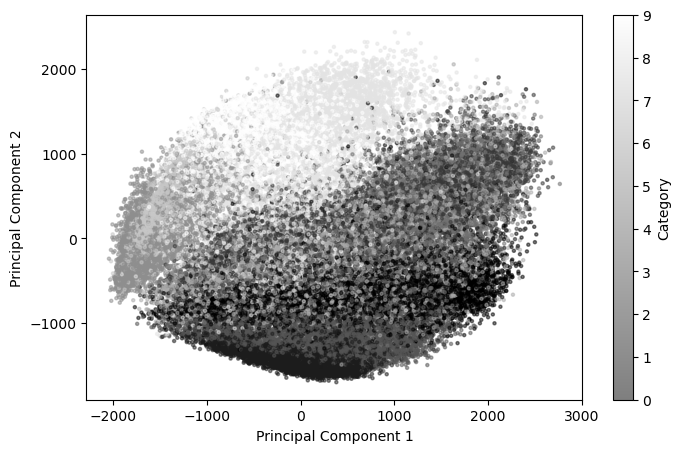

In [ ]:
# TODO: Implement

plt.figure(figsize=(8, 5))

plt.scatter(
    fm_X_2d[:, 0],
    fm_X_2d[:, 1],
    c=fm_y,
    s=5,
    alpha=0.5,
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Category")
plt.show()

## 3.4: ✏️ Reverse PCA
1. Use the inverse transform of a newly created 5-dimensional PCA to obtain the reconstructed image

In [30]:
# TODO: Implement

print(fm_X_pca.shape)
fm_X_reconstructed_5d = pca.inverse_transform(fm_X_pca)
print(fm_X_reconstructed_5d.shape)

(60000, 5)
(60000, 784)


2. Reshape the reconstructed images to the original shape and visualize them next to the original images

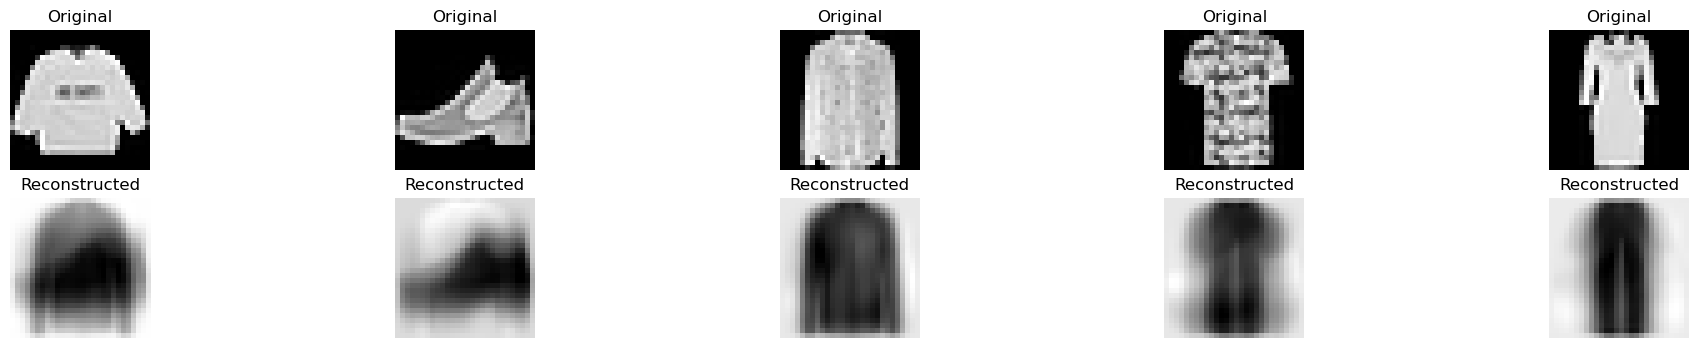

In [ ]:
num_samples = 5
fig, ax = plt.subplots(nrows=2, ncols=num_samples, figsize=(24, 4))
for i in range(num_samples):

    original_image = fm_X[i].reshape(28, 28)
    reconstructed_image = fm_X_reconstructed_5d[i].reshape(28, 28)

    ax[0,i].set_title("Original")
    ax[0,i].imshow(original_image, cmap="gray_r")
    ax[0,i].axis("off")

    ax[1,i].set_title("Reconstructed")
    ax[1,i].imshow(reconstructed_image, cmap="gray_r")
    ax[1,i].axis("off")


plt.show()

3. Redo the last two exercises with various number of components. Which changes do you notice in the resulting image?

In [32]:
num_comps = [1, 30, 100, 200, 784]
# TODO: Implement and answer


pca_list = []
pca_models = []
for comp in num_comps:
    pca = PCA(n_components=comp)
    fm_X_pca = pca.fit_transform(fm_X)
    pca_list.append(fm_X_pca)
    pca_models.append(pca)

reconstructed_image_list = []

for pca, fm_X_pca in zip(pca_models, pca_list):
    fm_X_reconstructed = pca.inverse_transform(fm_X_pca)
    reconstructed_image_list.append(fm_X_reconstructed)

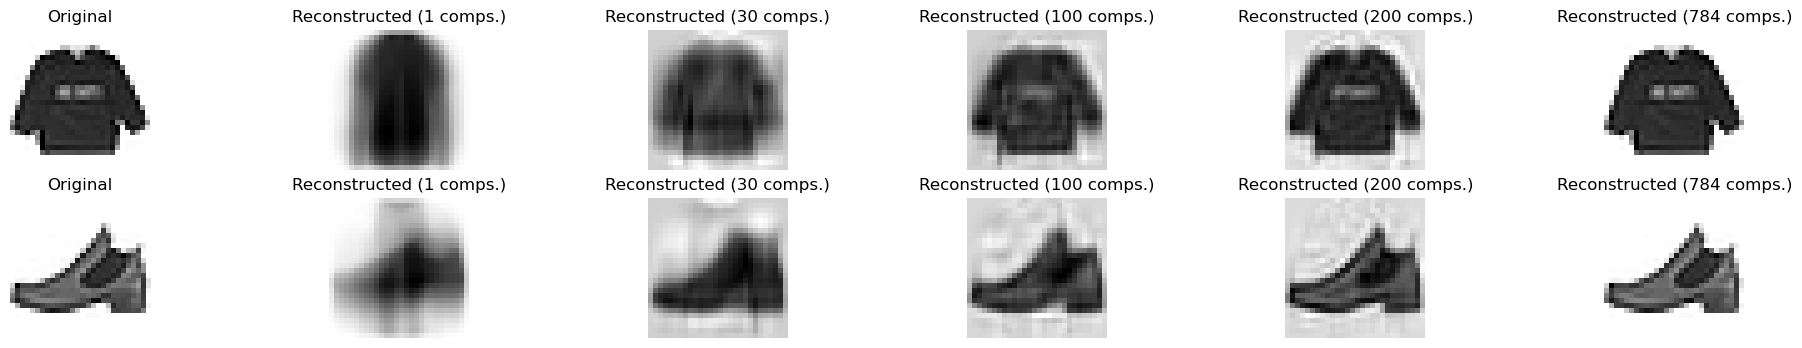

In [33]:
num_samples = 2
fig, ax = plt.subplots(
    nrows=num_samples,
    ncols=len(num_comps) + 1,
    figsize=(24, 4)
)
for i in range(num_samples):
    original_image = fm_X[i].reshape(28, 28)

    ax[i, 0].imshow(original_image, cmap="gray_r")
    ax[i, 0].set_title("Original")
    ax[i, 0].axis("off")

    for j, comp in enumerate(num_comps):
        reconstructed_image = reconstructed_image_list[j][i].reshape(28, 28)
        ax[i, j+1].imshow(reconstructed_image, cmap="gray_r")
        ax[i, j+1].set_title(f"Reconstructed ({comp} comps.)")
        ax[i, j+1].axis("off")

In [34]:
# When you increase the number of components, the reconstructed image becomes more similar to the original image. With only 1 component, the image is very blurry and lacks details.